<a href="https://colab.research.google.com/github/NadineAppiah/lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


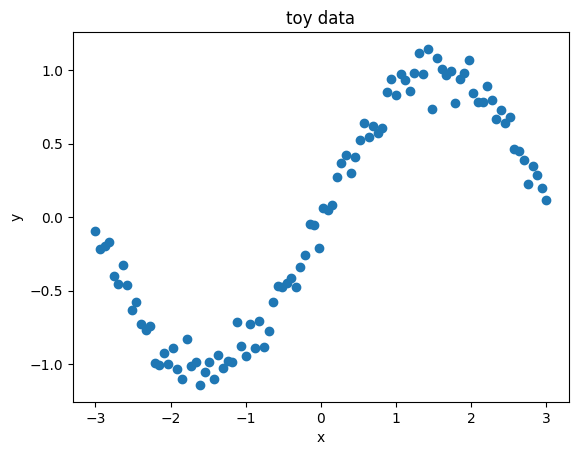

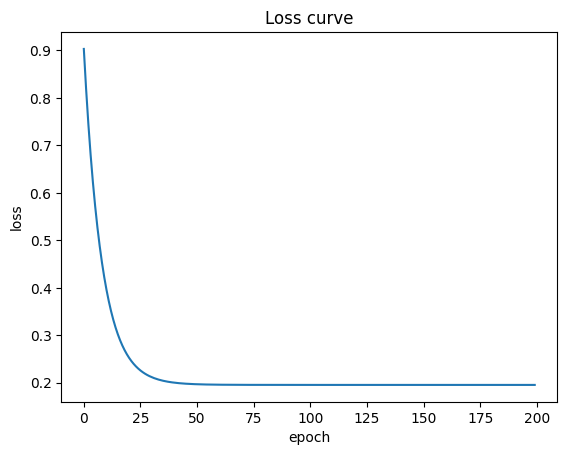

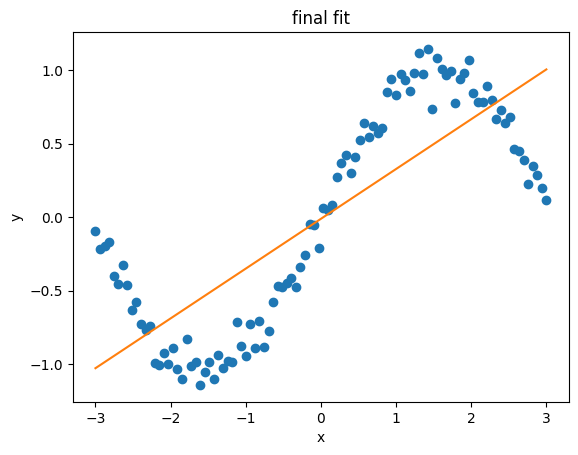

In [3]:
#Part 1.1
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)
plt.plot(x, y, 'o')
plt.title('toy data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

w = np.random.normal(0, 0.1, 1)
b = np.random.normal(0, 0.1, 1)

lr = 0.01
losses = []
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

plt.plot(losses)
plt.title('Loss curve')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

plt.plot(x, y, 'o')
plt.plot(x, w * x + b)
plt.title('final fit')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


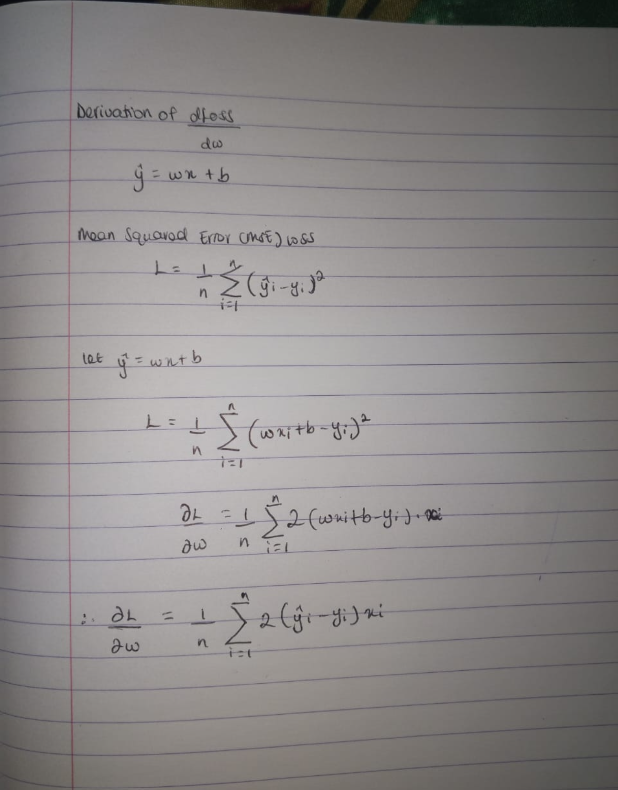
2. This is underfitting. The model is too simple for the data. A single neuron can only learn a straight line. A sine wave is nonlinear, so no matter how long the model is trained, the neuron will not be able to represent the curve.

Final loss:  0.15420016299690406


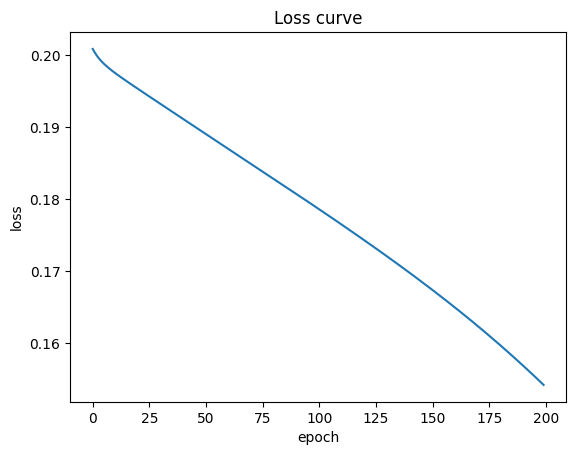

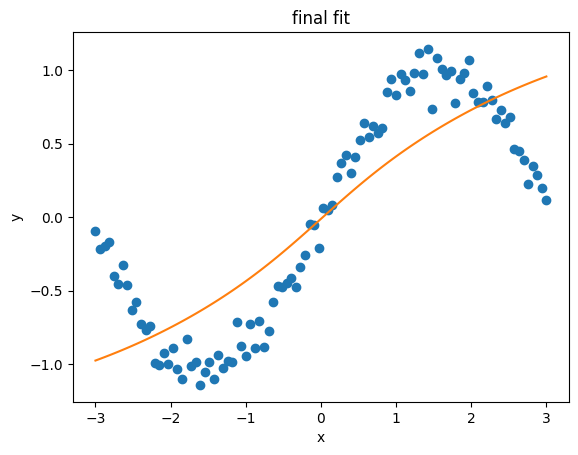

In [4]:
#Part 1.2
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

lr = 0.01
losses = []
for i in range(200):
  z1 = x @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat-y) ** 2)
  losses.append(loss)

  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

print("Final loss: ", losses[-1])

plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss curve')
plt.show()

plt.plot(x, y, 'o')
plt.plot(x, y_hat)
plt.title('final fit')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

**Depth and activations**

Removing tanh causes the model to underfit because it becomes a linear model.
1. A stack of linear layers is still linear because the composition of linear function is another linear function. Without an activation function, multiple layers collapse into a single linear layer.
2. The 8 hidden neurons act as different nonlinear features that capture different parts of sine wave.
3. Backpropagation is an algorithm that uses the chain rule to calculate how each parameter contributed to the error and updates the weights to reduce the loss.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_418/3889689048.py:21: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - current_y) ** 2)
/tmp/ipykernel_418/3889689048.py:27: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_418/3889689048.py:28: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


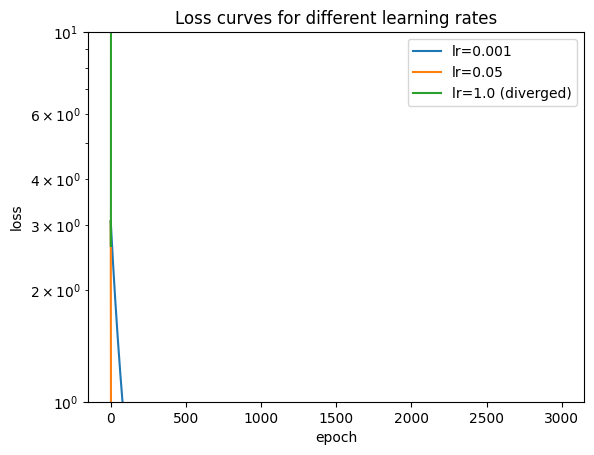

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#part 1.3
def train_toy(lr, steps = 3000):
    np.random.seed(RANDOM_STATE)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    current_x = x.copy()
    current_y = y.copy()

    losses = []
    for i in range(steps):
        z1 = current_x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - current_y) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - current_y) / len(current_y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = current_x.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    losses_arr = np.array(losses)
    bad = ~np.isfinite(losses_arr)
    if bad.any():
        first_bad = np.argmax(bad)
        return losses_arr[:first_bad].tolist()
    return losses_arr.tolist()

losses_1 = train_toy(0.001)
losses_2 = train_toy(0.05)
losses_3 = train_toy(1.0)
clipped_losses_3 = [loss for loss in losses_3 if np.isfinite(loss)]

plt.plot(range(len(losses_1)), losses_1, label='lr=0.001')
plt.plot(range(len(losses_2)), losses_2, label='lr=0.05')
plt.plot(range(len(clipped_losses_3)), clipped_losses_3, label='lr=1.0 (diverged)')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss curves for different learning rates')
plt.yscale('log')
plt.show()

**Learning rate**
The curve with lr = 0.001 decreases slowly because the weight updates are small, so learning takes longer.
The curve with lr = 0.05 decreases faster and converges well because the updates are large enough to update the model.
The curve with lr = 1.0 becomes unstable because the updates are too large, causing the model to overshoot the minimum and the loss to explode or oscillate.

A large learning rate does not simply make learning faster because gradient descent can jump past the optimal weights instead of gradually moving toward them.

In [6]:
#part 2.1
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

print(obesity.head())
print(obesity.shape)


binary_cols = ['family_history_with_overweight',
               'FAVC',
               'SMOKE',
               'SCC']

for col in binary_cols:
  obesity[col] = obesity[col].map({'no': 0, 'yes': 1})

obesity['Gender'] = obesity['Gender'].map({'Female': 0, 'Male': 1})

obesity = pd.get_dummies(obesity, columns=['MTRANS', 'CAEC', 'CALC'])

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
X = obesity.drop('NObeyesdad', axis=1)
y = label_encoder.fit_transform(obesity['NObeyesdad'])

print(label_encoder.classes_)

x_train, x_temp, y_train, y_temp = train_test_split(X, y,
                                    test_size=0.4, stratify=y,
                                    random_state=RANDOM_STATE)

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp,
                                                test_size=0.5, stratify=y_temp,
                                                random_state=RANDOM_STATE)
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = TensorDataset(x_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train size: ", len(train_loader.dataset))
print("Validation size: ", len(val_loader.dataset))
print("Test size: ", len(test_loader.dataset))

print(x_train.shape)
print(y_train.shape)

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

**Preprocessing for neural networks**
1. CrossEntropyLoss in Pytorch expects integer class labels because it applies softmax internally and compares the predicted probabilities with the correct class indexes. One-hot vectors use a single integer to identify the correct class.
2. Neural networks are sensitive to feature scaling because the gradients depend on the input values. Random forests do not rely on gradients, so they are less affected by feature scale.
3. shuffle = True randomly changes the order of training samples in each epoch. This helps produce a more stable and effective gradient updates during training.

In [7]:
#part 2.2
import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64,32), n_classes = 7):
      super().__init__()

      self.network = nn.Sequential(
        nn.Linear(input_dim, hidden_sizes[0]),
        nn.ReLU(),
        nn.Linear(hidden_sizes[0], hidden_sizes[1]),
        nn.ReLU(),
        nn.Linear(hidden_sizes[1], n_classes))

    def forward(self, x):
      return self.network(x)

input_dim = x_train.shape[1]
model = FeedForwardNet(input_dim).to(DEVICE)
print(model)

total_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(total_parameters)

nn.Linear(input_dim, 64)
first_layer = input_dim * 64 + 64
print(first_layer)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
4039
1728


**Architecture**
1. Parameter count
Parameters = (input sixe * output size) + bias

Layer 1: Input -> 64 neurons
(input_dim * 64) + 64

Layer 2: 64 -> 32 neurons
(64 * 32) + 32 = 2080

Output layer: 32 -> 7 classes
(32 * 7) + 7 = 231

total parameters = (input_dim * 64) + 64 + 2080 + 231

2. ReLU is used in deeper networks because it helps reduce the vanishing gradient problem and it simpler.
3. Without ReLU, multiple linear layers collapse into a single linear layer. Therefore the network will not be able to model complex patterns.

Epoch 1/50 - Train Loss: 1.8643 - Train Acc: 0.3160 - Val Loss: 1.7298 - Val Acc: 0.5379
Epoch 2/50 - Train Loss: 1.5637 - Train Acc: 0.5506 - Val Loss: 1.3759 - Val Acc: 0.5545
Epoch 3/50 - Train Loss: 1.1829 - Train Acc: 0.6074 - Val Loss: 1.0459 - Val Acc: 0.6374
Epoch 4/50 - Train Loss: 0.9080 - Train Acc: 0.6959 - Val Loss: 0.8825 - Val Acc: 0.7133
Epoch 5/50 - Train Loss: 0.7478 - Train Acc: 0.7654 - Val Loss: 0.7760 - Val Acc: 0.7583
Epoch 6/50 - Train Loss: 0.6377 - Train Acc: 0.7986 - Val Loss: 0.7083 - Val Acc: 0.7796
Epoch 7/50 - Train Loss: 0.5478 - Train Acc: 0.8199 - Val Loss: 0.6593 - Val Acc: 0.8104
Epoch 8/50 - Train Loss: 0.4763 - Train Acc: 0.8507 - Val Loss: 0.6039 - Val Acc: 0.8057
Epoch 9/50 - Train Loss: 0.4148 - Train Acc: 0.8633 - Val Loss: 0.5684 - Val Acc: 0.8412
Epoch 10/50 - Train Loss: 0.3596 - Train Acc: 0.8894 - Val Loss: 0.5368 - Val Acc: 0.8483
Epoch 11/50 - Train Loss: 0.3164 - Train Acc: 0.9084 - Val Loss: 0.5172 - Val Acc: 0.8602
Epoch 12/50 - Train

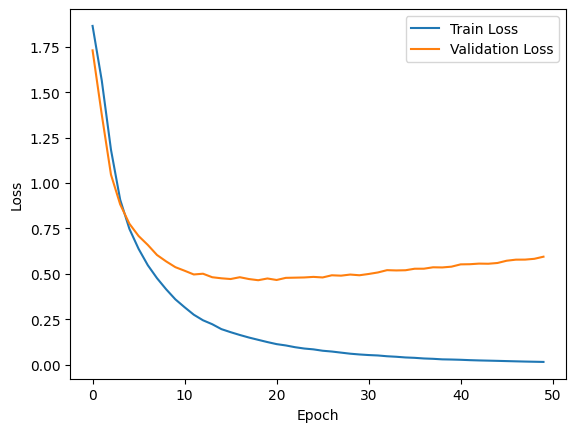

<function matplotlib.pyplot.show(close=None, block=None)>

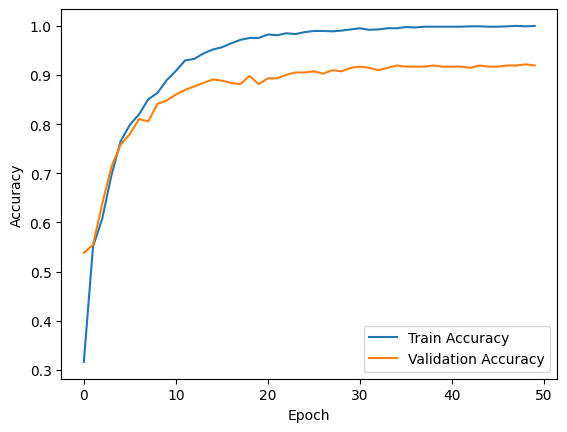

In [8]:
#part 2.3
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_acc = 0

for epoch in range(50):
  model.train()
  train_loss = 0
  train_acc = 0
  for xb, yb in train_loader:
    optimizer.zero_grad()

    logits = model(xb.to(DEVICE))
    loss = criterion(logits, yb.to(DEVICE))
    loss.backward()
    optimizer.step()

    train_loss += loss.item() * xb.size(0)
    train_acc += (logits.argmax(dim=1) == yb.to(DEVICE)).sum().item()

  train_loss /= len(train_loader.dataset)
  train_acc /= len(train_loader.dataset)
  train_losses.append(train_loss)
  train_accs.append(train_acc)

  model.eval()
  val_loss = 0
  val_acc = 0
  with torch.no_grad():
    for xb, yb in val_loader:
      logits = model(xb.to(DEVICE))
      loss = criterion(logits, yb.to(DEVICE))

      val_loss += loss.item() * xb.size(0)
      val_acc += (logits.argmax(dim=1) == yb.to(DEVICE)).sum().item()

  val_loss /= len(val_loader.dataset)
  val_acc /= len(val_loader.dataset)
  val_losses.append(val_loss)
  val_accs.append(val_acc)
  if val_acc > best_acc:
    best_acc = val_acc
    torch.save(model.state_dict(), "ffn_best.pt")
  print(f"Epoch {epoch+1}/{50} - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

model.load_state_dict(torch.load("ffn_best.pt"))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show

**Training**
1. **Forward pass**

NumPy
z1 = x @ W1 + b1

h = np.tanh(z1)

y_hat = h @ W2 + b2

loss = np.mean((y_hat - y)**2)

PyTorch
logits = model(xb)

loss = criterion(logits, yb)

**Gradient computation**

NumPy
d_yhat = 2 * (y_hat - y) / len(y)

dW2 = h.T @ d_yhat   

db2 = d_yhat.sum(axis=0)

dh   = d_yhat @ W2.T

dz1 = dh * (1 - np.tanh(z1) ** 2)

dW1 = x.T @ dz1  

db1 = dz1.sum(axis=0)

PyTorch
loss.backward()

**Parameter update**

NumPy
W1 -= lr * dW1
W2 -= lr * dW2

PyTorch
optimizer.step()


2. The model is overfitting.Th training accuracy reached 100% while the validation accuracy plateaued at 92%. The training loss continued to decrease to 0.0155, but the validation loss reached its lowest around 0.45 before decreasing to 0.5677.

3. optimizer.zero_grad() clears the gradients from the previous batch. Without resetting them, each batch would add new gradients to old ones, causing incorrect weight updates and unstable training.

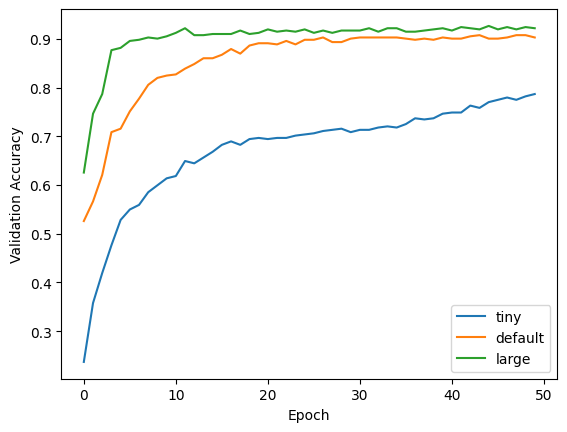

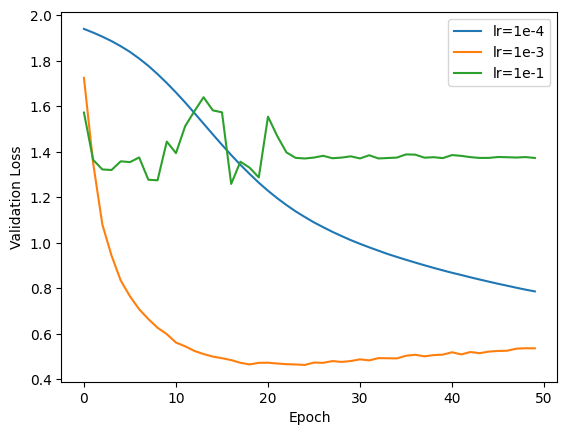

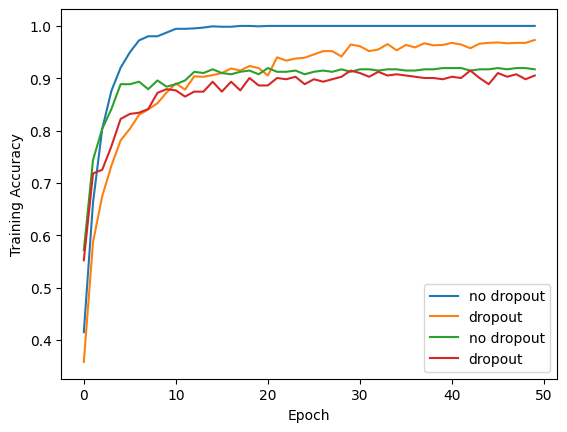

In [9]:
#part 2.4
class FeedForwardNet(nn.Module):

    def __init__(self, input_dim,
                 hidden_sizes=(64,32),
                 n_classes=7,
                 dropout=0.0):

        super().__init__()

        layers = []
        prev = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev = h

        layers.append(nn.Linear(prev, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def run_experiment(hidden_sizes=(64,32),lr=1e-3,batch_size=32,
                   epochs=50,dropout=0.0):

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = FeedForwardNet(
        input_dim=x_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb
                             )
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pred = torch.argmax(logits, dim=1)
            train_correct += (pred == yb).sum().item()
            train_total += yb.size(0)


        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item()
                pred = torch.argmax(logits, dim=1)
                val_correct += (pred == yb).sum().item()
                val_total += yb.size(0)

        history["train_loss"].append(train_loss/len(train_loader))
        history["val_loss"].append(val_loss/len(val_loader))

        history["train_acc"].append(train_correct/train_total)
        history["val_acc"].append(val_correct/val_total)

    return history

tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256,128,64))

plt.plot(tiny["val_acc"], label="tiny")
plt.plot(default["val_acc"], label="default")
plt.plot(large["val_acc"], label="large")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

lr_small = run_experiment(lr=1e-4)
lr_default = run_experiment(lr=1e-3)
lr_large = run_experiment(lr=1e-1)

plt.plot(lr_small["val_loss"], label="lr=1e-4")
plt.plot(lr_default["val_loss"], label="lr=1e-3")
plt.plot(lr_large["val_loss"], label="lr=1e-1")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

large_no_dropout = run_experiment(
    hidden_sizes=(256,128,64),dropout=0.0)

large_dropout = run_experiment(
    hidden_sizes=(256,128,64),dropout=0.3)

plt.plot(large_no_dropout["train_acc"], label="no dropout")
plt.plot(large_dropout["train_acc"], label="dropout")
plt.plot(large_no_dropout["val_acc"], label="no dropout")
plt.plot(large_dropout["val_acc"], label="dropout")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend()
plt.show()

**Experiments**
1. The largest network did not necessarily perform best on the validation data. While it achieved the highest training accuracy, its validation accuracy improved only slightly before levelling off, indicating diminishing returns. The gap between training and validation accuracy also increased, indicating some overfitting.
2. The results matched the toy problem in Part 1.3. A very small learning rate (1e-4) learned slowly, the default learning rate (1e-3) converged smoothly and achieved the best performance, while the large learning rate (1e-1) caused unstable training and poorer convergence.
3. Dropout reduced the gap between training and validation accuracy, making the model generalise better. It works by randomly turning off some neurons during training, preventing the network from relying too heavily on any single neuron and reducing overfitting.

Neural Network Test Accuracy: 0.9267139479905437
Neural Network Test Macro-F1: 0.9247007007649365

Neural Network Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.91      0.93        54
      Normal_Weight       0.77      0.84      0.80        58
     Obesity_Type_I       0.97      0.96      0.96        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.89      0.81      0.85        58
Overweight_Level_II       0.92      0.98      0.95        58

           accuracy                           0.93       423
          macro avg       0.93      0.92      0.92       423
       weighted avg       0.93      0.93      0.93       423



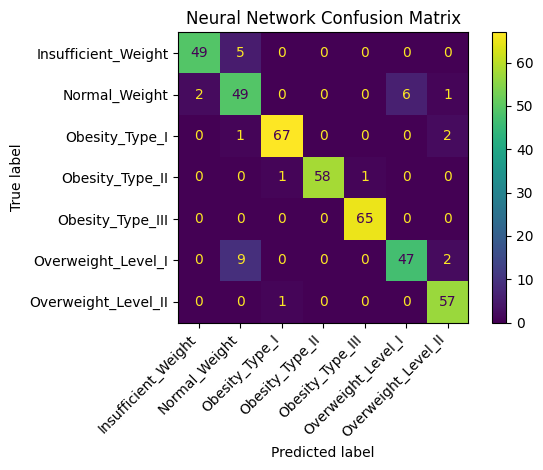


Logistic Regression Test Accuracy: 0.8368794326241135
Logistic Regression Test Macro-F1: 0.8305804267611591

Model Comparison:


,Test Accuracy,Test Macro-F1,Training Time,Parameters / Trees
Model,,,,
Logistic Regression (Lab 2),0.836879,0.830580,Very fast,N/A
Feedforward Neural Network (Lab 3),0.926714,0.924701,50 epochs,4039


In [13]:
#part 2.5
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt
import torch


model.load_state_dict(torch.load("ffn_best.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)

        logits = model(xb)
        predictions = torch.argmax(logits, dim=1)

        y_true.extend(yb.numpy())
        y_pred.extend(predictions.cpu().numpy())


test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro")

print("Neural Network Test Accuracy:", test_acc)
print("Neural Network Test Macro-F1:", test_f1)

print("\nNeural Network Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="viridis")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train.numpy(), y_train.numpy())

lr_predictions = log_reg.predict(x_test.numpy())

lr_accuracy = accuracy_score(y_test.numpy(), lr_predictions)
lr_f1 = f1_score(y_test.numpy(), lr_predictions, average="macro")

print("\nLogistic Regression Test Accuracy:", lr_accuracy)
print("Logistic Regression Test Macro-F1:", lr_f1)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Lab 2)",
        "Feedforward Neural Network (Lab 3)"
    ],
    "Test Accuracy": [
        lr_accuracy,
        test_acc
    ],
    "Test Macro-F1": [
        lr_f1,
        test_f1
    ],
    "Training Time": [
        "Very fast",
        "50 epochs"
    ],
    "Parameters / Trees": [
        "N/A",
        sum(p.numel() for p in model.parameters() if p.requires_grad)
    ]
})

comparison.set_index("Model", inplace=True)

print("\nModel Comparison:")
display(comparison)

**Final evaluation**
1. The neural network mainly confuses Normal Weight with Overweight_Level_I, and occasionally confuses nearby obesity categories. In contrast, the Logistic Regression model from Lab 2 commonly confused Overweight_Level_I and Overweight_Level_II. Both models struggle with neighbouring weight categories because these classes have similar characteristics, making them harder to separate.
2. The Feedforward Neural Network performed better than Logistic Regression, achieving a test accuracy of 92.67% and Macro-F1 of 92.47%, compared with Logistic Regression's approximately 90% accuracy and F1 score. The improvement is noticeable but not extremely large, meaning the extra complexity of deep learning provided some benefit on this dataset. Deep learning would be more valuable when working with larger datasets or problems involving complex non-linear patterns, such as image, audio, or text classification.

**Reflection**
1. loss.backward() calculates the gradients of the loss with respect to each model parameter using backpropagation and the chain rule. It determines how much each weight and bias contributed to the error. optimizer.step() then updates the parameters by applying the learning rate to those gradients, moving the model towards lower loss.
2. I would choose the learning rate because it directly controls how quickly and effectively the model learns.
3. The biggest train-validation gap was seen with the larger networks, where training accuracy continued increasing close to 100% while validation accuracy stopped improving. The intervention that reduced the gap most was dropout.
4. A plain MLP may struggle with images because it treats every pixel as an independent feature and does not understand spatial relationships between nearby pixels. A better architecture should be able to capture local patterns and preserve spatial structure, which is why Convolutional Neural Networks (CNNs) are more suitable for image tasks.